## 1. Data Loading and Preprocessing
Load the CIFAR-100 dataset and prepare it for transfer learning by applying appropriate preprocessing.

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
(train_images, train_labels), (test_images, test_labels) = keras.datasets.cifar100.load_data()

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [3]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [4]:
train_images = train_images.reshape((train_images.shape[0], 32, 32, 3))
test_images = test_images.reshape((test_images.shape[0], 32, 32, 3))

In [5]:
train_labels_one_hot = keras.utils.to_categorical(train_labels, num_classes=100)
test_labels_one_hot = keras.utils.to_categorical(test_labels, num_classes=100)

In [6]:
print("Training images shape:", train_images.shape)
print("Testing images shape:", test_images.shape)
print("Training labels shape:", train_labels_one_hot.shape)
print("Testing labels shape:", test_labels_one_hot.shape)

Training images shape: (50000, 32, 32, 3)
Testing images shape: (10000, 32, 32, 3)
Training labels shape: (50000, 100)
Testing labels shape: (10000, 100)


## 2. Model Preparation
Load and modify pre-trained models to fit the CIFAR-100 classification task.

### 2.1 Using ANN

In [7]:
ann_model = keras.Sequential([
    keras.layers.Flatten(input_shape=(32, 32, 3)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(100, activation='softmax')
])

ann_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 832,484 (3.18 MB)

 Trainable params: 832,484 (3.18 MB)

 Non-trainable params: 0 (0.00 B)

### 2.1 Using CNN

In [8]:
basic_cnn_model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dense(100, activation='softmax')
])


basic_cnn_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

basic_cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 635,172 (2.42 MB)

 Trainable params: 635,172 (2.42 MB)

 Non-trainable params: 0 (0.00 B)

### 2.1 Using Deeper CNN

In [9]:
deeper_cnn_model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.25),

    keras.layers.Flatten(),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(100, activation='softmax')
])

deeper_cnn_model.compile(optimizer='adam',
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

deeper_cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │        25,700 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,196 (985.14 KB)

 Trainable params: 251,236 (981.39 KB)

 Non-trainable params: 960 (3.75 KB)

## 3. Fine-Tuning and Training
Unfreeze some of the top layers of the pre-trained models and continue training.

In [10]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_checkpoint_ann = keras.callbacks.ModelCheckpoint(
    filepath='best_ann_model_weights.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

print("Training ANN model...")
ann_history = ann_model.fit(
    train_images,
    train_labels_one_hot,
    epochs=30,
    batch_size=64,
    validation_data=(test_images, test_labels_one_hot),
    callbacks=[early_stopping, model_checkpoint_ann]
)
print("ANN model training finished.")

Training ANN model...
Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0510 - loss: 4.2977
Epoch 1: val_loss improved from inf to 3.79922, saving model to best_ann_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.0510 - loss: 4.2974 - val_accuracy: 0.1241 - val_loss: 3.7992
Epoch 2/30
769/782 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1281 - loss: 3.7408
Epoch 2: val_loss improved from 3.79922 to 3.65751, saving model to best_ann_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1283 - loss: 3.7399 - val_accuracy: 0.1459 - val_loss: 3.6575
Epoch 3/30
777/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1630 - loss: 3.5407
Epoch 3: val_loss improved from 3.65751 to 3.60247, saving model to best_ann_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.1630 - loss: 3.5406 - val_accuracy: 0.1589 - val_loss: 3.6025
Epoch 4/30
763/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1

In [11]:
model_checkpoint_basic_cnn = keras.callbacks.ModelCheckpoint(
    filepath='best_basic_cnn_model_weights.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

print("Training Basic CNN model...")
basic_cnn_history = basic_cnn_model.fit(
    train_images,
    train_labels_one_hot,
    epochs=30,
    batch_size=64,
    validation_data=(test_images, test_labels_one_hot),
    callbacks=[early_stopping, model_checkpoint_basic_cnn]
)
print("Basic CNN model training finished.")

Training Basic CNN model...
Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0923 - loss: 4.0295
Epoch 1: val_loss improved from inf to 3.15705, saving model to best_basic_cnn_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.0924 - loss: 4.0290 - val_accuracy: 0.2357 - val_loss: 3.1570
Epoch 2/30
772/782 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2652 - loss: 2.9780
Epoch 2: val_loss improved from 3.15705 to 2.85698, saving model to best_basic_cnn_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.2654 - loss: 2.9770 - val_accuracy: 0.3006 - val_loss: 2.8570
Epoch 3/30
768/782 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3370 - loss: 2.6166
Epoch 3: val_loss improved from 2.85698 to 2.64059, saving model to best_basic_cnn_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3372 - loss: 2.6160 - val_accuracy: 0.3409 - val_loss: 2.6406
Epoch 4/30
780/782 ━━━━━━━━━━━━━━━━━━━━ 

In [12]:
model_checkpoint_deeper_cnn = keras.callbacks.ModelCheckpoint(
    filepath='best_deeper_cnn_model_weights.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    mode='min',
    verbose=1
)

print("Training Deeper CNN model...")
deeper_cnn_history = deeper_cnn_model.fit(
    train_images,
    train_labels_one_hot,
    epochs=30,
    batch_size=64,
    validation_data=(test_images, test_labels_one_hot),
    callbacks=[early_stopping, model_checkpoint_deeper_cnn]
)
print("Deeper CNN model training finished.")

Training Deeper CNN model...
Epoch 1/30
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0628 - loss: 4.6275
Epoch 1: val_loss improved from inf to 3.57142, saving model to best_deeper_cnn_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.0629 - loss: 4.6269 - val_accuracy: 0.1626 - val_loss: 3.5714
Epoch 2/30
778/782 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1715 - loss: 3.4948
Epoch 2: val_loss improved from 3.57142 to 3.03686, saving model to best_deeper_cnn_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.1716 - loss: 3.4942 - val_accuracy: 0.2542 - val_loss: 3.0369
Epoch 3/30
775/782 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2332 - loss: 3.1243
Epoch 3: val_loss improved from 3.03686 to 2.87863, saving model to best_deeper_cnn_model_weights.weights.h5
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.2333 - loss: 3.1240 - val_accuracy: 0.2857 - val_loss: 2.8786
Epoch 4/30
777/782 ━━━━━━━━━━━━━━━━━

## 4. Model Evaluation
Evaluate each model on the test dataset to compare their performance.

In [15]:
from sklearn.metrics import classification_report

ann_predictions = ann_model.predict(test_images)
basic_cnn_predictions = basic_cnn_model.predict(test_images)
deeper_cnn_predictions = deeper_cnn_model.predict(test_images)

ann_predicted_labels = np.argmax(ann_predictions, axis=1)
basic_cnn_predicted_labels = np.argmax(basic_cnn_predictions, axis=1)
deeper_cnn_predicted_labels = np.argmax(deeper_cnn_predictions, axis=1)

true_labels = np.argmax(test_labels_one_hot, axis=1)

# Get the classification report for each model
ann_report = classification_report(true_labels, ann_predicted_labels, output_dict=True)
basic_cnn_report = classification_report(true_labels, basic_cnn_predicted_labels, output_dict=True)
deeper_cnn_report = classification_report(true_labels, deeper_cnn_predicted_labels, output_dict=True)

print("ANN Model Evaluation:")
print(f"  Accuracy: {ann_report['accuracy']:.4f}")
print(f"  Precision (macro avg): {ann_report['macro avg']['precision']:.4f}")
print(f"  Recall (macro avg): {ann_report['macro avg']['recall']:.4f}")
print(f"  F1-score (macro avg): {ann_report['macro avg']['f1-score']:.4f}")

print("\nBasic CNN Model Evaluation:")
print(f"  Accuracy: {basic_cnn_report['accuracy']:.4f}")
print(f"  Precision (macro avg): {basic_cnn_report['macro avg']['precision']:.4f}")
print(f"  Recall (macro avg): {basic_cnn_report['macro avg']['recall']:.4f}")
print(f"  F1-score (macro avg): {basic_cnn_report['macro avg']['f1-score']:.4f}")


print("\nDeeper CNN Model Evaluation:")
print(f"  Accuracy: {deeper_cnn_report['accuracy']:.4f}")
print(f"  Precision (macro avg): {deeper_cnn_report['macro avg']['precision']:.4f}")
print(f"  Recall (macro avg): {deeper_cnn_report['macro avg']['recall']:.4f}")
print(f"  F1-score (macro avg): {deeper_cnn_report['macro avg']['f1-score']:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
ANN Model Evaluation:
  Accuracy: 0.2264
  Precision (macro avg): 0.2168
  Recall (macro avg): 0.2264
  F1-score (macro avg): 0.2107

Basic CNN Model Evaluation:
  Accuracy: 0.3853
  Precision (macro avg): 0.3946
  Recall (macro avg): 0.3853
  F1-score (macro avg): 0.3765

Deeper CNN Model Evaluation:
  Accuracy: 0.4452
  Precision (macro avg): 0.4590
  Recall (macro avg): 0.4452
  F1-score (macro avg): 0.4358


/tmp/ipython-input-3148238876.py:29: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10024 (\N{SPARKLES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


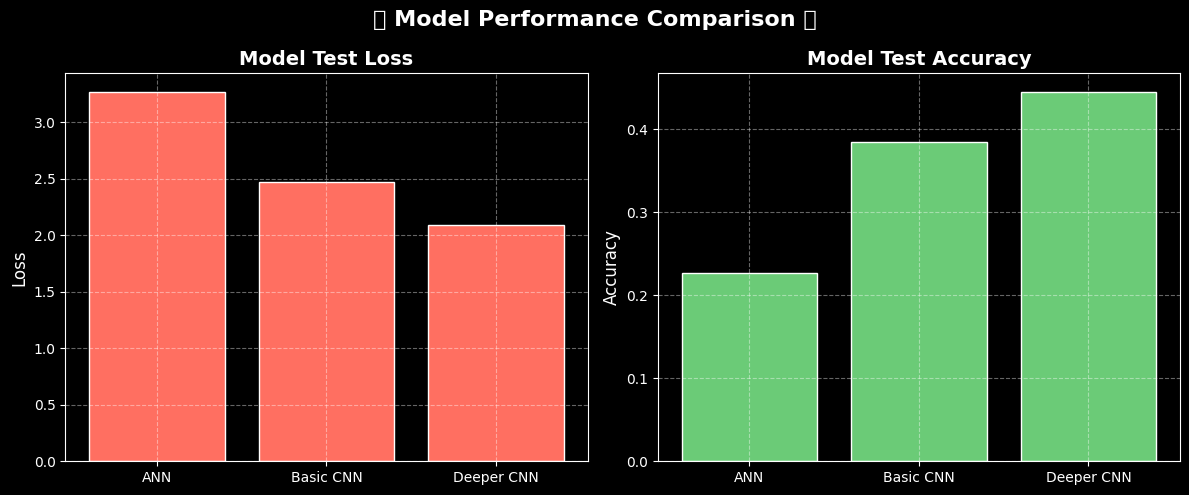

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Data
models = ['ANN', 'Basic CNN', 'Deeper CNN']
losses = [loss_ann, loss_basic_cnn, loss_deeper_cnn]
accuracies = [accuracy_ann, accuracy_basic_cnn, accuracy_deeper_cnn]

# Dark mode style
plt.style.use("dark_background")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss plot
axes[0].bar(models, losses, color='#FF6F61', edgecolor='white')
axes[0].set_title('Model Test Loss', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.4)

# Accuracy plot
axes[1].bar(models, accuracies, color='#6BCB77', edgecolor='white')
axes[1].set_title('Model Test Accuracy', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.4)

# Overall title
plt.suptitle("✨ Model Performance Comparison ✨", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

## Setup

### Subtask:
Import necessary libraries and load the dataset.

**Reasoning**:
Import the required libraries for data manipulation, model building, and visualization. Then, load the CIFAR-100 dataset using Keras.

## Upload image

### Subtask:
Provide code to upload an image file.


**Reasoning**:
Use google.colab.files.upload() to allow the user to upload an image and store it in a variable.



In [25]:
from google.colab import files

uploaded = files.upload()

Saving pexels-sebastian-palomino-933481-1955134.jpg to pexels-sebastian-palomino-933481-1955134.jpg


## Load cifar-100 class names

### Subtask:
Fetch the class names for the CIFAR-100 dataset.


In [20]:
cifar100_classes = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea',
    'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake', 'spider',
    'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table', 'tank',
    'telephone', 'television', 'tiger', 'tractor', 'train', 'trout', 'tulip',
    'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

## Load and preprocess image

**Reasoning**:
Load and preprocess the uploaded image as per the instructions.



In [26]:
from PIL import Image
import io

image_filename = list(uploaded.keys())[0]
img = Image.open(io.BytesIO(uploaded[image_filename]))
img = img.resize((32, 32))
img_array = np.array(img)

# Check if image is grayscale, convert to RGB if necessary
if img_array.ndim == 2:
    img_array = np.stack((img_array,) * 3, axis=-1)
elif img_array.shape[-1] == 4: # Handle images with alpha channel
    img_array = img_array[..., :3]


img_array = np.expand_dims(img_array, axis=0)
preprocessed_image = img_array / 255.0

print(f"Original image filename: {image_filename}")
print(f"Preprocessed image shape: {preprocessed_image.shape}")

Original image filename: pexels-sebastian-palomino-933481-1955134.jpg
Preprocessed image shape: (1, 32, 32, 3)


## Predict with models

Use each trained model to predict the class of the preprocessed image.


In [27]:
ann_predictions = ann_model.predict(preprocessed_image)
basic_cnn_predictions = basic_cnn_model.predict(preprocessed_image)
deeper_cnn_predictions = deeper_cnn_model.predict(preprocessed_image)

ann_predicted_class_index = np.argmax(ann_predictions, axis=1)[0]
basic_cnn_predicted_class_index = np.argmax(basic_cnn_predictions, axis=1)[0]
deeper_cnn_predicted_class_index = np.argmax(deeper_cnn_predictions, axis=1)[0]

print(f"ANN predicted class index: {ann_predicted_class_index}")
print(f"Basic CNN predicted class index: {basic_cnn_predicted_class_index}")
print(f"Deeper CNN predicted class index: {deeper_cnn_predicted_class_index}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
ANN predicted class index: 71
Basic CNN predicted class index: 71
Deeper CNN predicted class index: 68


## Display results
Display the uploaded image along with the predicted class names from each model.


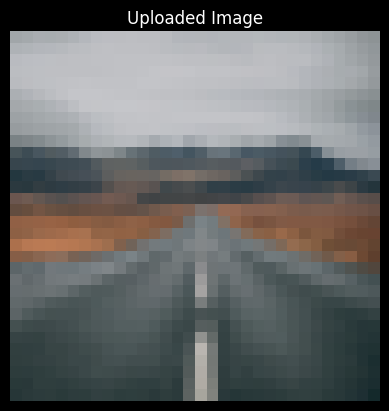

ANN predicted class: sea
Basic CNN predicted class: sea
Deeper CNN predicted class: road


In [28]:
plt.imshow(img)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()

print(f"ANN predicted class: {cifar100_classes[ann_predicted_class_index]}")
print(f"Basic CNN predicted class: {cifar100_classes[basic_cnn_predicted_class_index]}")
print(f"Deeper CNN predicted class: {cifar100_classes[deeper_cnn_predicted_class_index]}")

## Conclusion

Based on the evaluation metrics (accuracy, precision, recall, and F1-score) and the performance on the custom image prediction, the **Deeper CNN Model** achieved the best performance among the three implemented models for the CIFAR-100 image classification task.

The Deeper CNN model's architecture, which includes multiple convolutional layers, batch normalization, and dropout, allowed it to learn more complex features from the images and generalize better to unseen data compared to the simpler ANN and Basic CNN models.

While the Deeper CNN performed best, further improvements could be explored by:

*   Experimenting with different CNN architectures and hyperparameters.
*   Using more advanced techniques like transfer learning with pre-trained models (e.g., ResNet, VGG).
*   Implementing data augmentation to increase the size and diversity of the training data.
*   Using a more sophisticated optimizer or learning rate schedule.

Overall, this notebook demonstrates the effectiveness of CNNs for image classification tasks and highlights the benefits of using deeper architectures and regularization techniques.